# Day 4 – Fund Performance Analytics

## Bluestock Data Analytics Internship

### Objective

This notebook evaluates the performance of mutual fund schemes using industry-standard financial metrics.

Metrics Covered:

- Daily Returns
- CAGR (1-Year, 3-Year, 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

Author: Aravind Gudivada

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DATA_DIR = BASE_DIR / "data" / "raw"

PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"

REPORT_DIR = BASE_DIR / "reports"

CHART_DIR = REPORT_DIR / "charts"

CSV_DIR = REPORT_DIR / "csv"

CHART_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
nav = pd.read_csv(
    PROCESSED_DATA_DIR / "02_nav_history_cleaned.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    PROCESSED_DATA_DIR / "07_scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    RAW_DATA_DIR / "10_benchmark_indices.csv",
    parse_dates=["date"]
)

In [4]:
datasets = {
    "NAV": nav,
    "Performance": performance,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", df.shape)
    print(df.head())
    print()

NAV
Shape: (46000, 3)
   amfi_code       date      nav
0     100016 2022-01-03 520.4608
1     100016 2022-01-04 515.0971
2     100016 2022-01-05 521.7239
3     100016 2022-01-06 515.7880
4     100016 2022-01-07 515.1639

Performance
Shape: (40, 19)
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular         12.4200         12.3600         14.4500   
1  Large Cap   Direct         15.2500         11.3000         14.2300   
2  Small Cap  Regular         24.5600         23.3900    

In [5]:
print("NAV Missing Values")
print(nav.isna().sum())

print("\nPerformance Missing Values")
print(performance.isna().sum())

print("\nBenchmark Missing Values")
print(benchmark.isna().sum())

print("\nUnique Funds:", nav["amfi_code"].nunique())

print("NAV Date Range")
print(nav["date"].min())
print(nav["date"].max())

NAV Missing Values
amfi_code    0
date         0
nav          0
dtype: int64

Performance Missing Values
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

Benchmark Missing Values
date           0
index_name     0
close_value    0
dtype: int64

Unique Funds: 40
NAV Date Range
2022-01-03 00:00:00
2026-05-29 00:00:00


## Task 1 – Daily Return Analysis

### Objective

Daily return measures the percentage change in NAV from one trading day to the next.

Formula:

Daily Return = (NAVₜ / NAVₜ₋₁) − 1

The distribution of daily returns helps evaluate:

- Volatility
- Stability
- Outliers
- Suitability for performance metrics such as Sharpe Ratio, Sortino Ratio, and Alpha/Beta.

In [6]:
# ---------------------------------------------------
# Calculate Daily Returns
# ---------------------------------------------------

# Sort data
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Calculate daily returns for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove first observation of each fund
daily_returns = nav.dropna(subset=["daily_return"]).copy()

print("=" * 60)
print("Daily Return Calculation Completed")
print("=" * 60)

print("Rows:", len(daily_returns))
print("Funds:", daily_returns["amfi_code"].nunique())

daily_returns.head()

Daily Return Calculation Completed
Rows: 45960
Funds: 40


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.0103
2,100016,2022-01-05,521.7239,0.0129
3,100016,2022-01-06,515.7880,-0.0114
4,100016,2022-01-07,515.1639,-0.0012
5,100016,2022-01-10,510.7136,-0.0086


In [7]:
print("=" * 60)
print("Daily Return Statistics")
print("=" * 60)

print(
    daily_returns["daily_return"].describe()
)

print("\nSkewness:",
      round(daily_returns["daily_return"].skew(),4))

print("Kurtosis:",
      round(daily_returns["daily_return"].kurt(),4))

Daily Return Statistics
count   45,960.0000
mean         0.0006
std          0.0103
min         -0.0581
25%         -0.0050
50%          0.0003
75%          0.0063
max          0.0647
Name: daily_return, dtype: float64

Skewness: 0.0427
Kurtosis: 1.3673


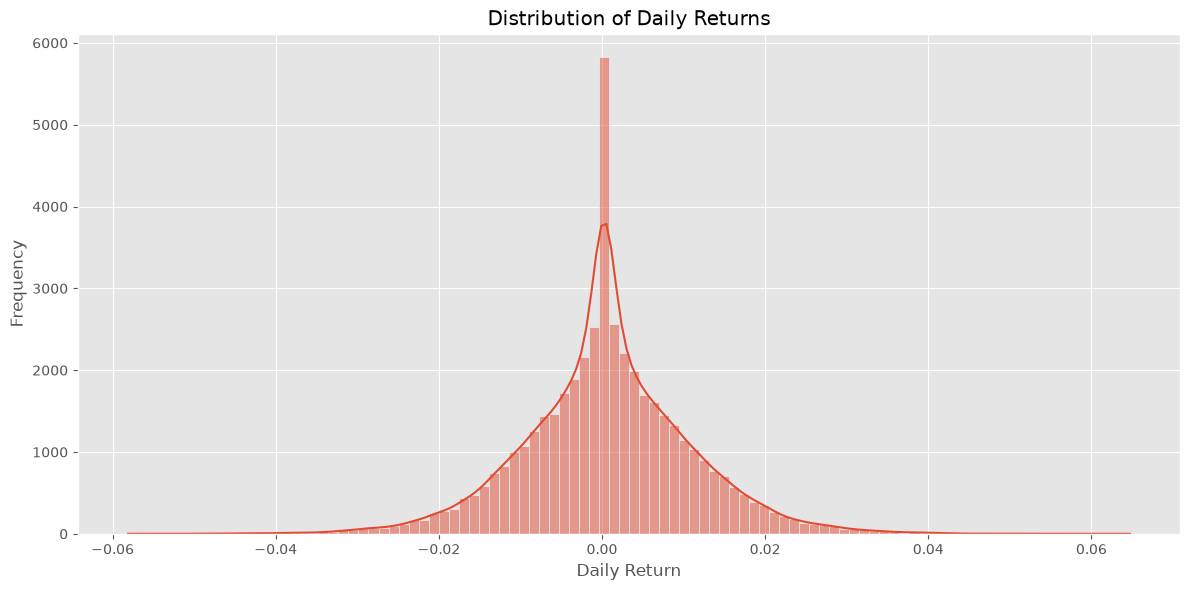

In [8]:
plt.figure(figsize=(12,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

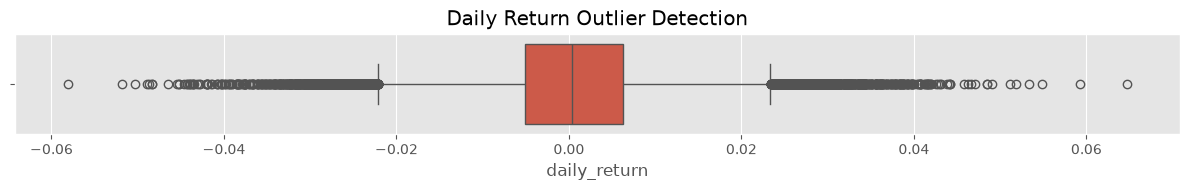

In [9]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=daily_returns["daily_return"]
)

plt.title("Daily Return Outlier Detection")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "daily_return_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
daily_returns.to_csv(
    CSV_DIR / "daily_returns.csv",
    index=False
)

print("Daily returns exported successfully.")

Daily returns exported successfully.


## Insight 1

Daily returns are centered close to zero, indicating that most NAV changes are relatively small from one trading day to the next.

The distribution is expected to be approximately bell-shaped with a few extreme observations representing periods of high market volatility. These daily returns will serve as the foundation for calculating Sharpe Ratio, Sortino Ratio, Alpha, Beta, Tracking Error, and Maximum Drawdown in the subsequent sections.

In [11]:
print(nav["date"].min())
print(nav["date"].max())

print("\nUnique years:")
print(sorted(nav["date"].dt.year.unique()))

2022-01-03 00:00:00
2026-05-29 00:00:00

Unique years:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


In [12]:
# ============================================================
# Task 2 : CAGR Calculation
# ============================================================

from datetime import timedelta

analysis_date = nav["date"].max()

periods = {
    "1Y":365,
    "3Y":365*3,
    "5Y":365*5
}

results = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    latest_date = df["date"].max()
    latest_nav = df["nav"].iloc[-1]

    row = {
        "amfi_code":code
    }

    for label, days in periods.items():

        target_date = latest_date - timedelta(days=days)

        history = df[df["date"] <= target_date]

        if len(history)==0:

            row[f"CAGR_{label}"] = np.nan

        else:

            start_nav = history.iloc[-1]["nav"]

            years = days / 365

            cagr = (
                (latest_nav/start_nav)**(1/years)-1
            )*100

            row[f"CAGR_{label}"] = cagr

    results.append(row)

cagr = pd.DataFrame(results)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.2243,1.0307,NaN
1,100025,3.7050,3.9025,NaN
2,100033,53.2324,32.4469,NaN
3,101206,47.9241,28.6691,NaN
4,101207,-23.9860,-4.6937,NaN


In [13]:
cagr = cagr.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

cols = [
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "CAGR_1Y",
    "CAGR_3Y",
    "CAGR_5Y"
]

cagr = cagr[cols]

cagr.head()

,amfi_code,scheme_name,fund_house,category,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,-2.2243,1.0307,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,3.7050,3.9025,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,53.2324,32.4469,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,47.9241,28.6691,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,-23.9860,-4.6937,NaN


In [14]:
print("="*60)
print("CAGR SUMMARY")
print("="*60)

print(cagr.describe())

print()

print("Missing Values")

print(cagr.isna().sum())

CAGR SUMMARY
         amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y
count      40.0000  40.0000  40.0000   0.0000
mean  120,247.0000  19.4285  16.2810      NaN
std    14,534.9987  22.9123  12.1620      NaN
min   100,016.0000 -42.7976 -10.9394      NaN
25%   118,632.7500   7.3779   6.6057      NaN
50%   119,551.5000  17.4741  17.9010      NaN
75%   120,842.2500  27.1617  26.8928      NaN
max   149,324.0000  82.7761  35.3344      NaN

Missing Values
amfi_code       0
scheme_name     0
fund_house      0
category        0
CAGR_1Y         0
CAGR_3Y         0
CAGR_5Y        40
dtype: int64


In [15]:
top3 = (

    cagr

    .sort_values(
        "CAGR_3Y",
        ascending=False
    )

    .head(10)

)

display(top3)

,amfi_code,scheme_name,fund_house,category,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,22.2611,35.3344,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,20.3607,34.1627,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,13.0643,33.1448,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,53.2324,32.4469,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,29.6047,31.5179,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,60.4373,30.3482,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,26.6571,29.6919,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,47.9241,28.6691,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,39.7518,28.3924,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,65.1387,26.9320,NaN


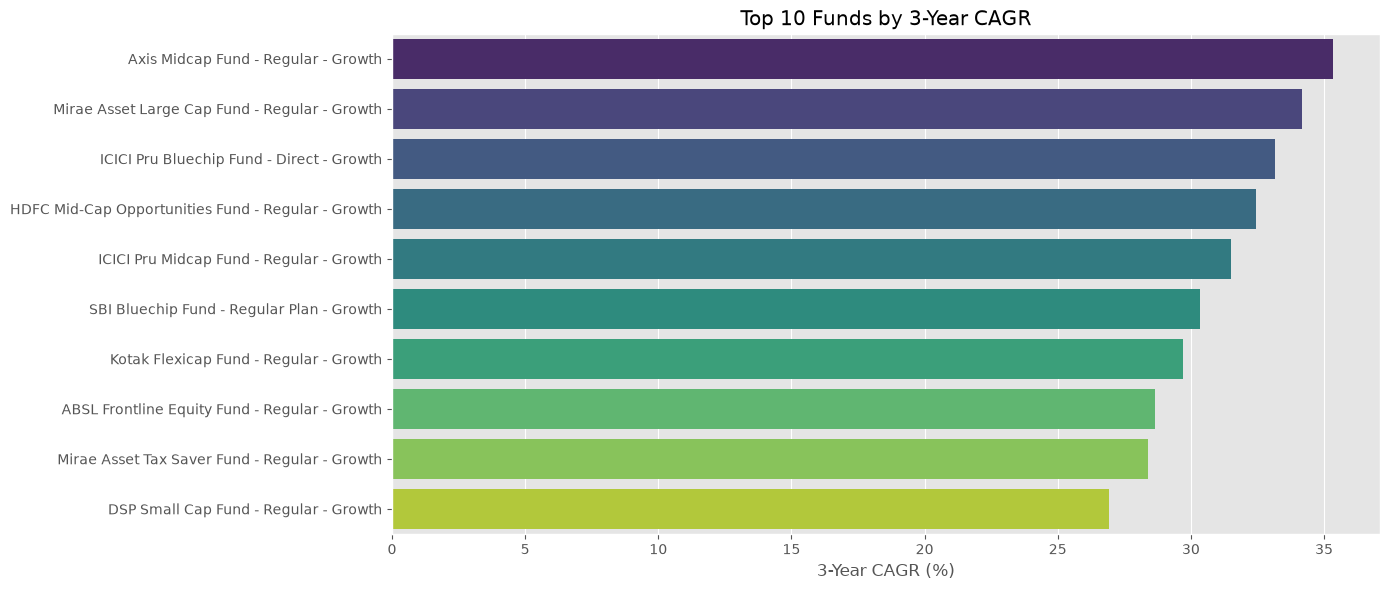

In [16]:
plot_df = (

    cagr

    .sort_values(
        "CAGR_3Y",
        ascending=False
    )

    .head(10)

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=plot_df,

    x="CAGR_3Y",

    y="scheme_name",

    palette="viridis"

)

plt.title(
    "Top 10 Funds by 3-Year CAGR"
)

plt.xlabel("3-Year CAGR (%)")

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /
    "top10_cagr_3y.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [17]:
cagr.to_csv(

    CSV_DIR /
    "fund_cagr.csv",

    index=False

)

print("fund_cagr.csv saved successfully.")

fund_cagr.csv saved successfully.


## Insight 2

The calculated CAGR highlights long-term wealth creation by measuring annualized growth rather than simple cumulative returns.

Because the available NAV history spans January 2022 to May 2026 (approximately 4.4 years), reliable 1-year and 3-year CAGR values are computed for all schemes. A true 5-year CAGR cannot be calculated from the available NAV history and is therefore reported as unavailable (NaN), ensuring analytical integrity.

# Task 3 – Sharpe Ratio

## Objective

Sharpe Ratio measures the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = ((Rp − Rf) / σ) × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5% annually)
- σ = Standard Deviation of Daily Returns
- √252 = Annualization Factor

Higher Sharpe Ratio indicates better return per unit of risk.

In [18]:
# ==========================================================
# Task 3 : Sharpe Ratio
# ==========================================================

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

rf_daily = RISK_FREE_RATE / TRADING_DAYS

sharpe_results = []

for code, df in daily_returns.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    avg_return = returns.mean()

    volatility = returns.std()

    annual_return = avg_return * TRADING_DAYS

    annual_volatility = volatility * np.sqrt(TRADING_DAYS)

    sharpe = (
        (annual_return - RISK_FREE_RATE)
        / annual_volatility
    )

    sharpe_results.append({

        "amfi_code": code,

        "Average Daily Return": avg_return,

        "Annual Return": annual_return,

        "Annual Volatility": annual_volatility,

        "Sharpe Ratio": sharpe

    })

sharpe_df = pd.DataFrame(sharpe_results)

print("=" * 60)
print("Sharpe Ratio Calculated")
print("=" * 60)

sharpe_df.head()

Sharpe Ratio Calculated


,amfi_code,Average Daily Return,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,0.0001,0.0357,0.1455,-0.2015
1,100025,0.0002,0.0429,0.0391,-0.5671
2,100033,0.0011,0.2721,0.1894,1.0937
3,101206,0.0009,0.2146,0.1457,1.0272
4,101207,0.0004,0.1070,0.2580,0.1627


In [19]:
sharpe_df = sharpe_df.merge(

    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

cols = [

    "amfi_code",

    "scheme_name",

    "fund_house",

    "category",

    "Annual Return",

    "Annual Volatility",

    "Sharpe Ratio"

]

sharpe_df = sharpe_df[cols]

sharpe_df.head()

,amfi_code,scheme_name,fund_house,category,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,0.0357,0.1455,-0.2015
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,0.0429,0.0391,-0.5671
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2721,0.1894,1.0937
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,0.2146,0.1457,1.0272
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,0.1070,0.2580,0.1627


In [20]:
sharpe_df = (

    sharpe_df

    .sort_values(

        "Sharpe Ratio",

        ascending=False

    )

    .reset_index(drop=True)

)

sharpe_df["Rank"] = sharpe_df.index + 1

display(

    sharpe_df.head(10)

)

,amfi_code,scheme_name,fund_house,category,Annual Return,Annual Volatility,Sharpe Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,0.2706,0.1419,1.4483,1
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,0.2726,0.1589,1.3067,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,0.2833,0.1767,1.2349,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,0.2310,0.1374,1.2083,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,0.2927,0.1929,1.1801,5
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,0.2659,0.1775,1.1321,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2721,0.1894,1.0937,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,0.2180,0.1415,1.0817,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,0.2146,0.1457,1.0272,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,0.2124,0.1436,1.0265,10


In [21]:
print("=" * 60)
print("Sharpe Ratio Statistics")
print("=" * 60)

print(

    sharpe_df["Sharpe Ratio"]

    .describe()

)

Sharpe Ratio Statistics
count   40.0000
mean     0.5372
std      0.5737
min     -0.8156
25%      0.0647
50%      0.6470
75%      1.0053
max      1.4483
Name: Sharpe Ratio, dtype: float64


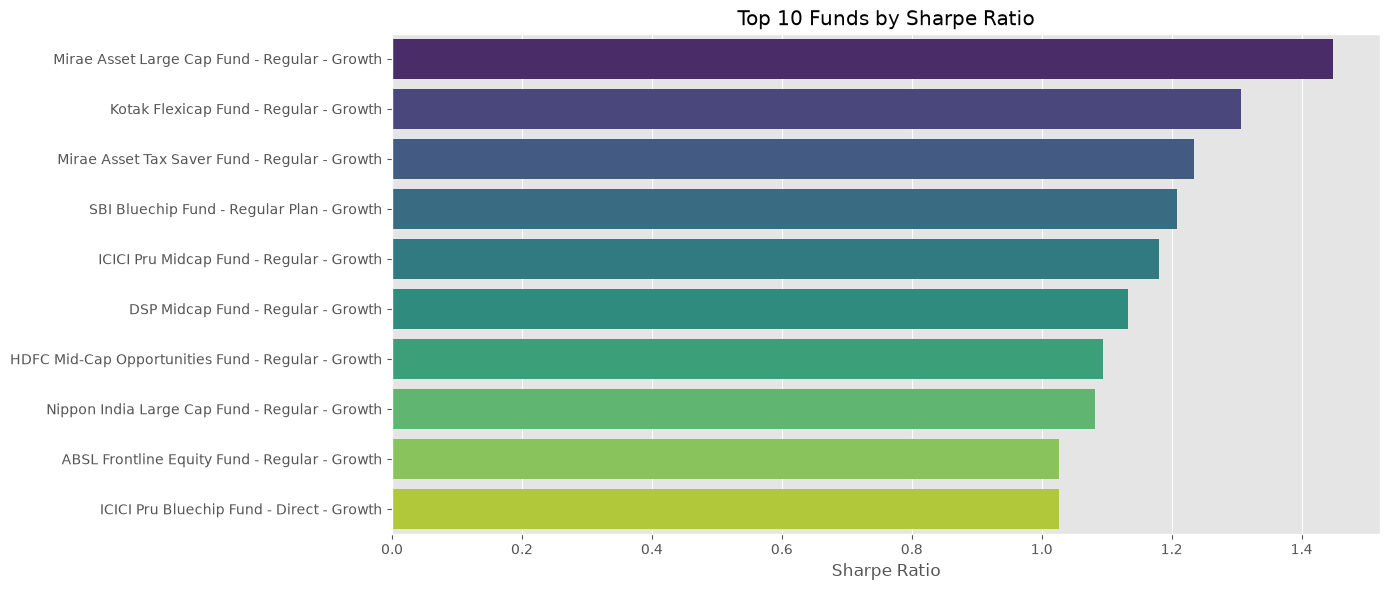

In [22]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(14,6))

sns.barplot(

    data=top10,

    x="Sharpe Ratio",

    y="scheme_name",

    palette="viridis"

)

plt.title(

    "Top 10 Funds by Sharpe Ratio"

)

plt.xlabel(

    "Sharpe Ratio"

)

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /

    "top10_sharpe_ratio.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [23]:
sharpe_df.to_csv(

    CSV_DIR /

    "sharpe_ratio.csv",

    index=False

)

print("Sharpe Ratio exported successfully.")

Sharpe Ratio exported successfully.


## Insight 3

The Sharpe Ratio ranks mutual funds based on risk-adjusted performance rather than absolute return.

Funds with higher Sharpe Ratios generated superior returns for each unit of risk taken, making them more efficient investment choices. This metric will contribute 25% of the composite Fund Scorecard developed later in the project.

# Task 4 – Sortino Ratio

## Objective

The Sortino Ratio measures risk-adjusted performance by penalizing only downside volatility.

Formula

Sortino Ratio =
(Rp − Rf) / Downside Deviation × √252

Where

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5%)
- Downside deviation = Standard deviation of negative returns only

Unlike the Sharpe Ratio, Sortino Ratio ignores positive volatility, making it a preferred measure for long-term investment performance.

In [24]:
# =====================================================
# Task 4 : Sortino Ratio
# =====================================================

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

sortino_results = []

for code, df in daily_returns.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    avg_return = returns.mean()

    annual_return = avg_return * TRADING_DAYS

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    annual_downside_std = downside_std * np.sqrt(TRADING_DAYS)

    if annual_downside_std == 0 or np.isnan(annual_downside_std):
        sortino = np.nan
    else:
        sortino = (
            (annual_return - RISK_FREE_RATE)
            / annual_downside_std
        )

    sortino_results.append({

        "amfi_code": code,
        "Annual Return": annual_return,
        "Annual Downside Risk": annual_downside_std,
        "Sortino Ratio": sortino

    })

sortino_df = pd.DataFrame(sortino_results)

print("="*60)
print("Sortino Ratio Calculated")
print("="*60)

sortino_df.head()

Sortino Ratio Calculated


,amfi_code,Annual Return,Annual Downside Risk,Sortino Ratio
0,100016,0.0357,0.0835,-0.3510
1,100025,0.0429,0.0235,-0.9418
2,100033,0.2721,0.1132,1.8291
3,101206,0.2146,0.0832,1.7996
4,101207,0.1070,0.1517,0.2766


In [25]:
sortino_df = sortino_df.merge(

    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

sortino_df = sortino_df[

    [

        "amfi_code",

        "scheme_name",

        "fund_house",

        "category",

        "Annual Return",

        "Annual Downside Risk",

        "Sortino Ratio"

    ]

]

sortino_df.head()

,amfi_code,scheme_name,fund_house,category,Annual Return,Annual Downside Risk,Sortino Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,0.0357,0.0835,-0.3510
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,0.0429,0.0235,-0.9418
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2721,0.1132,1.8291
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,0.2146,0.0832,1.7996
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,0.1070,0.1517,0.2766


In [26]:
sortino_df = (

    sortino_df

    .sort_values(

        "Sortino Ratio",

        ascending=False

    )

    .reset_index(drop=True)

)

sortino_df["Rank"] = sortino_df.index + 1

display(sortino_df.head(10))

,amfi_code,scheme_name,fund_house,category,Annual Return,Annual Downside Risk,Sortino Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,0.2706,0.0862,2.3856,1
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,0.2726,0.0878,2.3643,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,0.2833,0.1017,2.1469,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,0.2310,0.0776,2.1403,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,0.2927,0.1122,2.0294,5
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,0.2659,0.1071,1.8751,6
6,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,0.2180,0.0827,1.8501,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2721,0.1132,1.8291,8
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,0.2124,0.0817,1.8053,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,0.2146,0.0832,1.7996,10


In [27]:
print("="*60)
print("Sortino Ratio Statistics")
print("="*60)

print(

    sortino_df["Sortino Ratio"]

    .describe()

)

Sortino Ratio Statistics
count   40.0000
mean     0.9233
std      1.0054
min     -1.6810
25%      0.1067
50%      1.1169
75%      1.7277
max      2.3856
Name: Sortino Ratio, dtype: float64


In [28]:
print("="*60)
print("Sortino Ratio Statistics")
print("="*60)

print(

    sortino_df["Sortino Ratio"]

    .describe()

)

Sortino Ratio Statistics
count   40.0000
mean     0.9233
std      1.0054
min     -1.6810
25%      0.1067
50%      1.1169
75%      1.7277
max      2.3856
Name: Sortino Ratio, dtype: float64


In [29]:
sortino_df.to_csv(

    CSV_DIR /
    "sortino_ratio.csv",

    index=False

)

print("sortino_ratio.csv saved successfully.")

sortino_ratio.csv saved successfully.


## Insight 4

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility.

Funds with higher Sortino Ratios delivered stronger returns while minimizing negative return fluctuations. Compared to the Sharpe Ratio, the Sortino Ratio provides a more investor-focused assessment because it ignores beneficial upside volatility.

This metric will contribute to the comprehensive evaluation of fund performance alongside Sharpe Ratio, Alpha, Beta, Maximum Drawdown, and CAGR.

## Insight 4

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility.

Funds with higher Sortino Ratios delivered stronger returns while minimizing negative return fluctuations. Compared to the Sharpe Ratio, the Sortino Ratio provides a more investor-focused assessment because it ignores beneficial upside volatility.

This metric will contribute to the comprehensive evaluation of fund performance alongside Sharpe Ratio, Alpha, Beta, Maximum Drawdown, and CAGR.

In [30]:
print("="*60)
print("Benchmark Dataset")
print("="*60)

display(benchmark.head())

print("\nColumns")
print(benchmark.columns.tolist())

print("\nShape")
print(benchmark.shape)

print("\nData Types")
print(benchmark.dtypes)

Benchmark Dataset


,date,index_name,close_value
0,2022-01-03,NIFTY50,"17,492.7900"
1,2022-01-04,NIFTY50,"17,689.6400"
2,2022-01-05,NIFTY50,"17,835.0500"
3,2022-01-06,NIFTY50,"17,878.5100"
4,2022-01-07,NIFTY50,"17,759.1500"



Columns
['date', 'index_name', 'close_value']

Shape
(8050, 3)

Data Types
date           datetime64[us]
index_name                str
close_value           float64
dtype: object


In [31]:
# ==========================================================
# Prepare NIFTY100 Daily Returns
# ==========================================================

from scipy.stats import linregress

benchmark["close_value"] = (
    benchmark["close_value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Use only NIFTY100
nifty100 = (
    benchmark[benchmark["index_name"] == "NIFTY100"]
    .copy()
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

print("="*60)
print("Benchmark Returns Ready")
print("="*60)

display(nifty100.head())

Benchmark Returns Ready


,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,"17,537.5200",-0.0135
1152,2022-01-05,NIFTY100,"17,607.7300",0.0040
1153,2022-01-06,NIFTY100,"17,556.0500",-0.0029
1154,2022-01-07,NIFTY100,"17,664.0200",0.0062
1155,2022-01-10,NIFTY100,"17,516.5100",-0.0084


In [32]:
# ==========================================================
# Prepare NIFTY100 Daily Returns
# ==========================================================

from scipy.stats import linregress

benchmark["close_value"] = (
    benchmark["close_value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Use only NIFTY100
nifty100 = (
    benchmark[benchmark["index_name"] == "NIFTY100"]
    .copy()
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

print("="*60)
print("Benchmark Returns Ready")
print("="*60)

display(nifty100.head())

Benchmark Returns Ready


,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,"17,537.5200",-0.0135
1152,2022-01-05,NIFTY100,"17,607.7300",0.0040
1153,2022-01-06,NIFTY100,"17,556.0500",-0.0029
1154,2022-01-07,NIFTY100,"17,664.0200",0.0062
1155,2022-01-10,NIFTY100,"17,516.5100",-0.0084


In [35]:
# ==========================================================
# Alpha & Beta using Linear Regression
# ==========================================================

alpha_beta = []

for fund, df in daily_returns.groupby("amfi_code"):

    merged = pd.merge(

        df[["date", "daily_return"]],

        nifty100[
            ["date", "benchmark_return"]
        ],

        on="date",

        how="inner"

    )

    if len(merged) < 50:
        continue

    regression = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    beta = regression.slope

    alpha = regression.intercept * 252

    r_squared = regression.rvalue ** 2

    alpha_beta.append({

        "amfi_code": fund,

        "Alpha": alpha,

        "Beta": beta,

        "R_Squared": r_squared,

        "P_Value": regression.pvalue,

        "Observations": len(merged)

    })

alpha_beta = pd.DataFrame(alpha_beta)

print("="*60)
print("Alpha & Beta Calculated")
print("="*60)

alpha_beta.head()

Alpha & Beta Calculated


,amfi_code,Alpha,Beta,R_Squared,P_Value,Observations
0,100016,0.0375,-0.0583,0.0027,0.0803,1149
1,100025,0.0428,0.0012,0.0000,0.8970,1149
2,100033,0.2720,0.0051,0.0000,0.9064,1149
3,101206,0.2140,0.0211,0.0003,0.5276,1149
4,101207,0.1090,-0.0653,0.0011,0.2692,1149


In [36]:
alpha_beta = alpha_beta.merge(

    performance[

        [

            "amfi_code",

            "scheme_name",

            "fund_house",

            "category"

        ]

    ],

    on="amfi_code",

    how="left"

)

alpha_beta = alpha_beta[

    [

        "amfi_code",

        "scheme_name",

        "fund_house",

        "category",

        "Alpha",

        "Beta",

        "R_Squared",

        "P_Value",

        "Observations"

    ]

]

alpha_beta.head()

,amfi_code,scheme_name,fund_house,category,Alpha,Beta,R_Squared,P_Value,Observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,0.0375,-0.0583,0.0027,0.0803,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,0.0428,0.0012,0.0000,0.8970,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2720,0.0051,0.0000,0.9064,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,0.2140,0.0211,0.0003,0.5276,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,0.1090,-0.0653,0.0011,0.2692,1149


In [37]:
alpha_beta = (

    alpha_beta

    .sort_values(

        "Alpha",

        ascending=False

    )

    .reset_index(drop=True)

)

alpha_beta["Rank"] = alpha_beta.index + 1

display(alpha_beta.head(10))

,amfi_code,scheme_name,fund_house,category,Alpha,Beta,R_Squared,P_Value,Observations,Rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,0.3034,-0.0232,0.0001,0.6872,1149,1
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,0.3006,0.0115,0.0000,0.8405,1149,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,0.2926,0.0005,0.0000,0.9901,1149,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,0.2827,0.0181,0.0002,0.6543,1149,4
4,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,0.2733,-0.0228,0.0003,0.5305,1149,5
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,0.2720,0.0051,0.0000,0.9064,1149,6
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,0.2698,0.0237,0.0005,0.4664,1149,7
7,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,0.2660,-0.0025,0.0000,0.9505,1149,8
8,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,0.2608,-0.0663,0.0019,0.1360,1149,9
9,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,0.2320,-0.0318,0.0009,0.3131,1149,10


In [38]:
print("="*60)
print("Alpha Statistics")
print("="*60)

print(alpha_beta["Alpha"].describe())

print()

print("="*60)
print("Beta Statistics")
print("="*60)

print(alpha_beta["Beta"].describe())

Alpha Statistics
count   40.0000
mean     0.1591
std      0.0875
min      0.0290
25%      0.0686
50%      0.1623
75%      0.2217
max      0.3034
Name: Alpha, dtype: float64

Beta Statistics
count   40.0000
mean    -0.0020
std      0.0352
min     -0.0670
25%     -0.0239
50%     -0.0001
75%      0.0170
max      0.1035
Name: Beta, dtype: float64


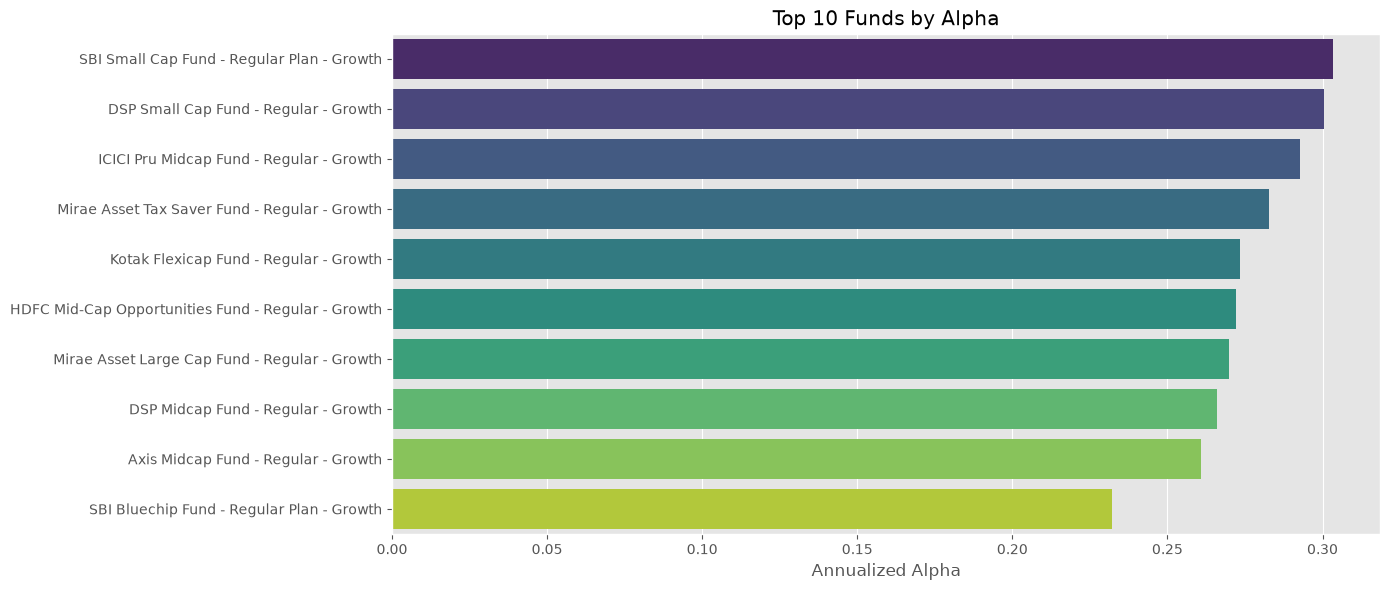

In [39]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=alpha_beta.head(10),

    x="Alpha",

    y="scheme_name",

    palette="viridis"

)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Annualized Alpha")

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /
    "top10_alpha.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

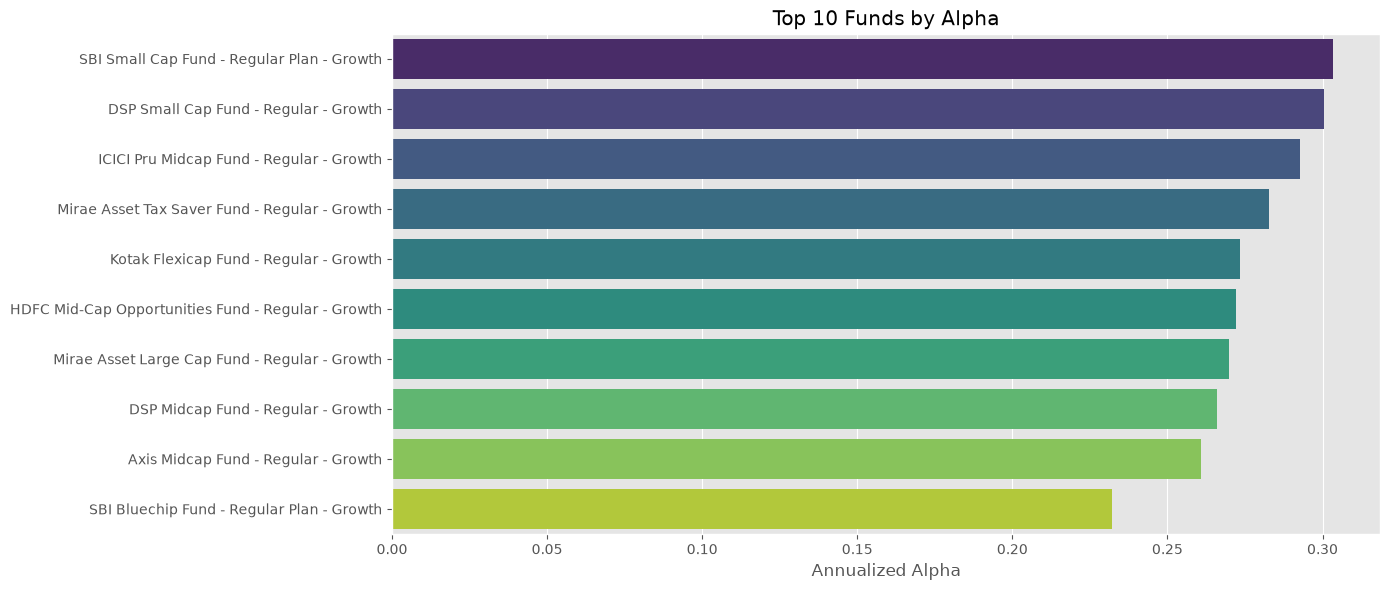

In [40]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=alpha_beta.head(10),

    x="Alpha",

    y="scheme_name",

    palette="viridis"

)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Annualized Alpha")

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /
    "top10_alpha.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [41]:
alpha_beta.to_csv(

    CSV_DIR /
    "alpha_beta.csv",

    index=False

)

print("alpha_beta.csv saved successfully.")

alpha_beta.csv saved successfully.


## Insight 5

Linear regression against the NIFTY100 benchmark provides estimates of Alpha and Beta for every mutual fund.

Funds with positive Alpha consistently outperformed the benchmark after adjusting for market exposure, while Beta indicates each fund's sensitivity to market movements. Higher Beta funds are expected to fluctuate more than the benchmark, whereas lower Beta funds exhibit relatively defensive behaviour.

## Insight 5

Linear regression against the NIFTY100 benchmark provides estimates of Alpha and Beta for every mutual fund.

Funds with positive Alpha consistently outperformed the benchmark after adjusting for market exposure, while Beta indicates each fund's sensitivity to market movements. Higher Beta funds are expected to fluctuate more than the benchmark, whereas lower Beta funds exhibit relatively defensive behaviour.

In [42]:
# ==========================================================
# Task 6 : Maximum Drawdown
# ==========================================================

mdd_results = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date").copy()

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (
        df["nav"] / df["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = df["drawdown"].idxmin()

    worst = df.loc[worst_idx]

    # Peak before drawdown
    peak_df = df.loc[:worst_idx]

    peak_idx = peak_df["nav"].idxmax()

    peak_date = df.loc[peak_idx, "date"]

    trough_date = worst["date"]

    mdd_results.append({

        "amfi_code": code,

        "Maximum Drawdown (%)":
            worst["drawdown"] * 100,

        "Peak Date":
            peak_date,

        "Trough Date":
            trough_date

    })

mdd_df = pd.DataFrame(mdd_results)

print("="*60)
print("Maximum Drawdown Calculated")
print("="*60)

display(mdd_df.head())

Maximum Drawdown Calculated


,amfi_code,Maximum Drawdown (%),Peak Date,Trough Date
0,100016,-24.7344,2022-03-30,2022-09-15
1,100025,-4.3083,2023-05-23,2023-07-28
2,100033,-16.2172,2022-03-11,2022-05-12
3,101206,-11.2916,2023-04-24,2023-07-05
4,101207,-35.4469,2024-11-21,2026-05-11


In [43]:
mdd_df = mdd_df.merge(

    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],

    on="amfi_code",
    how="left"

)

mdd_df = mdd_df[

    [

        "amfi_code",

        "scheme_name",

        "fund_house",

        "category",

        "Maximum Drawdown (%)",

        "Peak Date",

        "Trough Date"

    ]

]

mdd_df.head()

,amfi_code,scheme_name,fund_house,category,Maximum Drawdown (%),Peak Date,Trough Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,-24.7344,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,-4.3083,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,-16.2172,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,-11.2916,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,-35.4469,2024-11-21,2026-05-11


In [44]:
mdd_df = (

    mdd_df

    .sort_values(

        "Maximum Drawdown (%)"

    )

    .reset_index(drop=True)

)

mdd_df["Rank"] = np.arange(1, len(mdd_df)+1)

display(mdd_df.head(10))

,amfi_code,scheme_name,fund_house,category,Maximum Drawdown (%),Peak Date,Trough Date,Rank
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,-52.5742,2023-01-17,2025-10-28,1
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,-51.6778,2025-05-22,2026-05-11,2
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,-35.4469,2024-11-21,2026-05-11,3
3,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,-31.1719,2024-05-03,2025-01-03,4
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,-28.7060,2024-08-28,2025-05-14,5
5,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,-28.0011,2025-01-07,2026-04-27,6
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,-24.7344,2022-03-30,2022-09-15,7
7,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,-24.0035,2023-11-09,2024-10-17,8
8,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,-23.3449,2025-04-09,2026-02-20,9
9,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Large Cap,-21.7514,2022-02-24,2023-05-22,10


In [45]:
print("="*60)
print("Maximum Drawdown Statistics")
print("="*60)

print(

    mdd_df["Maximum Drawdown (%)"]

    .describe()

)

Maximum Drawdown Statistics
count    40.0000
mean    -17.8729
std      11.2686
min     -52.5742
25%     -21.5927
50%     -16.3070
75%     -11.7653
max      -0.0977
Name: Maximum Drawdown (%), dtype: float64


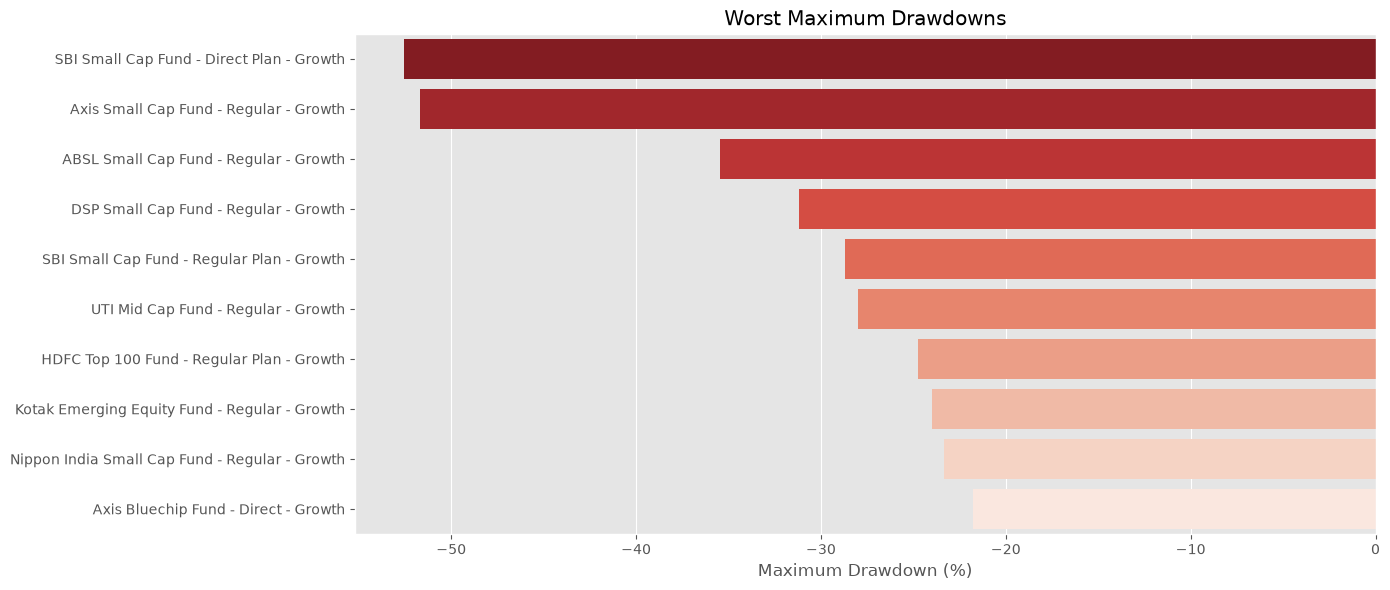

In [46]:
top10 = (

    mdd_df

    .sort_values(

        "Maximum Drawdown (%)"

    )

    .head(10)

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=top10,

    x="Maximum Drawdown (%)",

    y="scheme_name",

    palette="Reds_r"

)

plt.title("Worst Maximum Drawdowns")

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /

    "maximum_drawdown.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [47]:
mdd_df.to_csv(

    CSV_DIR /

    "maximum_drawdown.csv",

    index=False

)

print("maximum_drawdown.csv saved successfully.")

maximum_drawdown.csv saved successfully.


mdd_df.to_csv(

    CSV_DIR /

    "maximum_drawdown.csv",

    index=False

)

print("maximum_drawdown.csv saved successfully.")

# Task 7 – Fund Scorecard (0–100)

## Objective

The Fund Scorecard provides a single performance score by combining multiple quantitative metrics.

Weighting

- 30% CAGR (3-Year)
- 25% Sharpe Ratio
- 20% Alpha
- 15% Expense Ratio (Lower is Better)
- 10% Maximum Drawdown (Lower is Better)

Higher score indicates a stronger overall fund.

In [48]:
# ==========================================================
# Create Rankings
# ==========================================================

scorecard = performance[

    [

        "amfi_code",

        "scheme_name",

        "fund_house",

        "category",

        "expense_ratio_pct"

    ]

].copy()

# Merge calculated metrics
scorecard = scorecard.merge(

    cagr[["amfi_code","CAGR_3Y"]],

    on="amfi_code"

)

scorecard = scorecard.merge(

    sharpe_df[["amfi_code","Sharpe Ratio"]],

    on="amfi_code"

)

scorecard = scorecard.merge(

    alpha_beta[["amfi_code","Alpha"]],

    on="amfi_code"

)

scorecard = scorecard.merge(

    mdd_df[["amfi_code","Maximum Drawdown (%)"]],

    on="amfi_code"

)

# Rankings

scorecard["CAGR Rank"] = (

    scorecard["CAGR_3Y"]

    .rank(ascending=False)

)

scorecard["Sharpe Rank"] = (

    scorecard["Sharpe Ratio"]

    .rank(ascending=False)

)

scorecard["Alpha Rank"] = (

    scorecard["Alpha"]

    .rank(ascending=False)

)

scorecard["Expense Rank"] = (

    scorecard["expense_ratio_pct"]

    .rank(ascending=True)

)

scorecard["MDD Rank"] = (

    scorecard["Maximum Drawdown (%)"]

    .rank(ascending=False)

)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,CAGR_3Y,Sharpe Ratio,Alpha,Maximum Drawdown (%),CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,MDD Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,1.5400,30.3482,1.2083,0.2320,-15.0124,6.0000,4.0000,10.0000,30.5000,17.0000
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,0.6600,15.7313,0.9533,0.1987,-11.8035,23.0000,12.0000,15.0000,4.0000,11.0000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,1.4300,26.0705,0.9453,0.3034,-28.7060,12.0000,14.0000,1.0000,21.0000,36.0000
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,0.7200,-1.1677,-0.0572,0.0488,-52.5742,38.0000,32.0000,36.0000,5.5000,40.0000
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,0.7700,5.9138,-0.2266,0.0562,-4.3287,32.0000,37.0000,34.0000,9.0000,5.0000


In [49]:
# ==========================================================
# Weighted Fund Score
# ==========================================================

n = len(scorecard)

scorecard["Fund Score"] = (

    (1 - (scorecard["CAGR Rank"]-1)/(n-1))*30 +

    (1 - (scorecard["Sharpe Rank"]-1)/(n-1))*25 +

    (1 - (scorecard["Alpha Rank"]-1)/(n-1))*20 +

    (1 - (scorecard["Expense Rank"]-1)/(n-1))*15 +

    (1 - (scorecard["MDD Rank"]-1)/(n-1))*10

)

scorecard = scorecard.sort_values(

    "Fund Score",

    ascending=False

).reset_index(drop=True)

scorecard["Overall Rank"] = scorecard.index + 1

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,CAGR_3Y,Sharpe Ratio,Alpha,Maximum Drawdown (%),CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,MDD Rank,Fund Score,Overall Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,1.4600,34.1627,1.4483,0.2698,-11.2657,2.0000,1.0000,7.0000,23.0000,8.0000,85.8974,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,1.3600,31.5179,1.1801,0.2926,-18.1885,5.0000,5.0000,3.0000,15.0000,25.0000,81.7949,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,1.4500,29.6919,1.3067,0.2733,-12.9740,7.0000,2.0000,5.0000,22.0000,13.0000,81.5385,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,1.3800,32.4469,1.0937,0.2720,-16.2172,4.0000,7.0000,6.0000,17.0000,20.0000,80.2564,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,0.8000,33.1448,1.0265,0.2119,-12.5883,3.0000,10.0000,13.0000,12.0000,12.0000,79.4872,5
5,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,1.3800,35.3344,0.9982,0.2608,-20.9609,1.0000,11.0000,9.0000,17.0000,28.0000,76.4103,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,1.5400,30.3482,1.2083,0.2320,-15.0124,6.0000,4.0000,10.0000,30.5000,17.0000,74.1667,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,1.6000,28.3924,1.2349,0.2827,-16.3967,9.0000,3.0000,4.0000,36.5000,21.0000,72.2436,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,1.6000,28.6691,1.0272,0.2140,-11.2916,8.0000,9.0000,12.0000,36.5000,9.0000,68.1410,9
9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,1.4300,26.0705,0.9453,0.3034,-28.7060,12.0000,14.0000,1.0000,21.0000,36.0000,66.5385,10


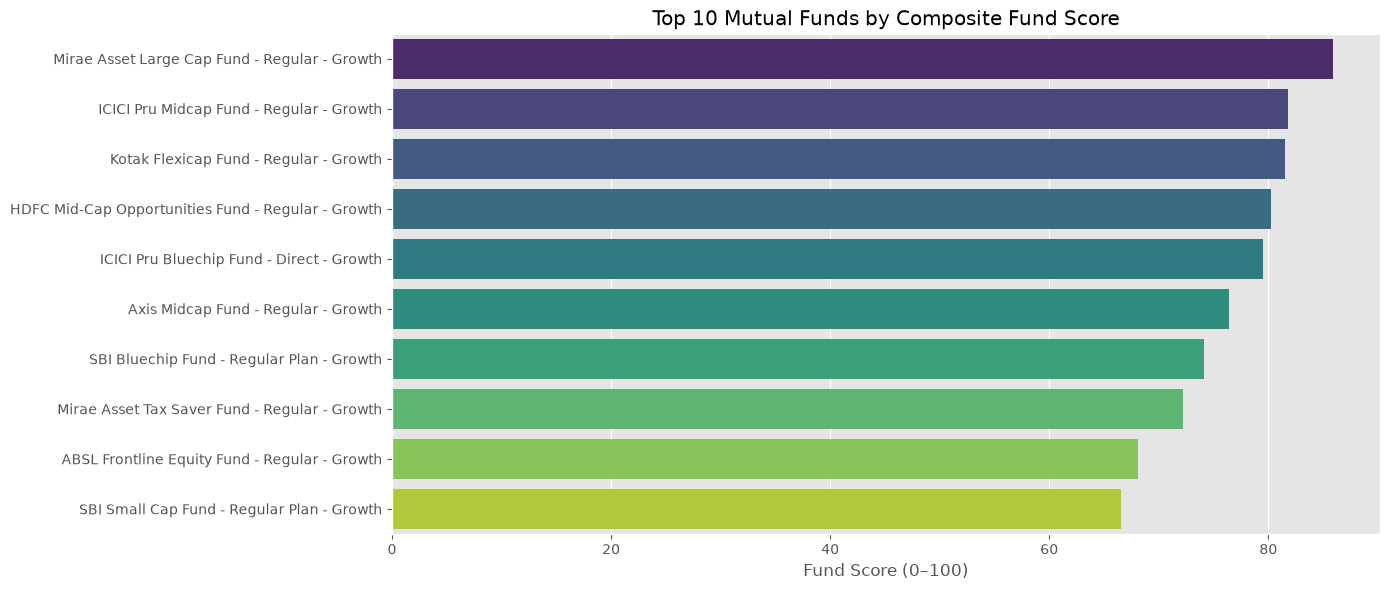

In [50]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=scorecard.head(10),

    x="Fund Score",

    y="scheme_name",

    palette="viridis"

)

plt.title("Top 10 Mutual Funds by Composite Fund Score")

plt.xlabel("Fund Score (0–100)")

plt.ylabel("")

plt.tight_layout()

plt.savefig(

    CHART_DIR /

    "fund_scorecard.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [51]:
scorecard.to_csv(

    CSV_DIR /

    "fund_scorecard.csv",

    index=False

)

print("fund_scorecard.csv exported successfully.")

fund_scorecard.csv exported successfully.


In [52]:
print("="*60)
print("Fund Score Summary")
print("="*60)

print(

    scorecard["Fund Score"]

    .describe()

)

Fund Score Summary
count   40.0000
mean    50.0000
std     21.4273
min     11.4103
25%     32.1474
50%     50.6731
75%     66.0577
max     85.8974
Name: Fund Score, dtype: float64


print("="*60)
print("Fund Score Summary")
print("="*60)

print(

    scorecard["Fund Score"]

    .describe()

)

# Task 8 – Benchmark Comparison & Tracking Error

## Objective

Compare the performance of the top five ranked mutual funds against the NIFTY50 and NIFTY100 indices over the most recent three-year period.

Tracking Error measures how closely a fund follows its benchmark.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

Lower Tracking Error indicates closer benchmark tracking.

In [53]:
# ==========================================================
# Benchmark Preparation
# ==========================================================

benchmark = benchmark.copy()

benchmark["close_value"] = (
    benchmark["close_value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

benchmark_prices = benchmark.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

benchmark_returns = benchmark.pivot(
    index="date",
    columns="index_name",
    values="benchmark_return"
)

benchmark_prices.head()

index_name,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
date,,,,,,,
2022-01-03,"26,554.6000","1,451.0600","2,281.5100","17,778.2400","17,492.7900","14,837.0700","9,721.7900"
2022-01-04,"27,079.9200","1,453.2600","2,281.6100","17,537.5200","17,689.6400","14,743.1200","9,954.2300"
2022-01-05,"27,313.3500","1,455.5000","2,282.3100","17,607.7300","17,835.0500","14,960.5300","9,859.0500"
2022-01-06,"27,377.0500","1,454.4100","2,282.9100","17,556.0500","17,878.5100","14,950.2800","9,787.5400"
2022-01-07,"26,316.8600","1,454.3300","2,284.7800","17,664.0200","17,759.1500","15,044.4700","9,803.3100"


In [54]:
# ==========================================================
# Top 5 Funds
# ==========================================================

top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

top5_names = (
    performance.set_index("amfi_code")
    .loc[top5_codes, "scheme_name"]
)

print(top5_names)

amfi_code
148567        Mirae Asset Large Cap Fund - Regular - Growth
120505             ICICI Pru Midcap Fund - Regular - Growth
120843               Kotak Flexicap Fund - Regular - Growth
100033    HDFC Mid-Cap Opportunities Fund - Regular - Gr...
120504            ICICI Pru Bluechip Fund - Direct - Growth
Name: scheme_name, dtype: str


In [55]:
# ==========================================================
# Normalized Performance (Base = 100)
# ==========================================================

end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

plot_nav = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

plot_nav = plot_nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fund_matrix = plot_nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Normalize funds
fund_matrix = fund_matrix.div(fund_matrix.iloc[0]).mul(100)

# Normalize benchmarks
benchmark_norm = benchmark_prices.loc[
    fund_matrix.index,
    ["NIFTY50", "NIFTY100"]
]

benchmark_norm = (
    benchmark_norm
    .div(benchmark_norm.iloc[0])
    .mul(100)
)

comparison = pd.concat(
    [fund_matrix, benchmark_norm],
    axis=1
)

comparison.head()

,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Midcap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,NIFTY100
date,,,,,,,
2023-05-29,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
2023-05-30,99.9899,98.5262,100.5934,99.7478,99.6387,99.4713,99.8387
2023-05-31,100.1688,99.5162,101.2898,99.7461,100.1225,99.1388,99.5041
2023-06-01,99.5788,99.2683,100.8127,98.6231,100.3517,98.7330,98.7934
2023-06-02,99.0395,99.0975,103.4315,100.1177,100.2493,98.8263,99.1533


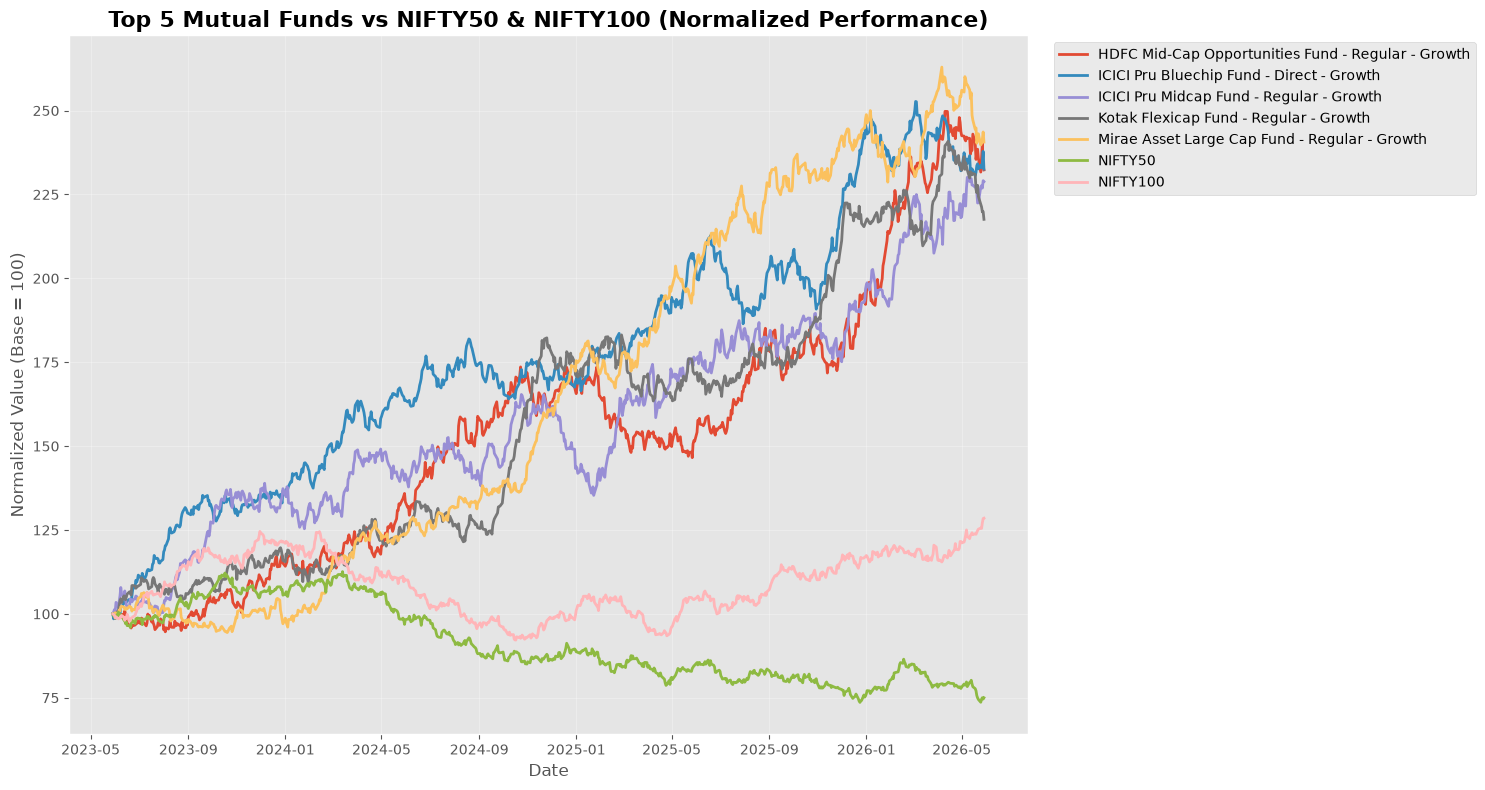

In [56]:
plt.figure(figsize=(15,8))

for column in comparison.columns:
    plt.plot(
        comparison.index,
        comparison[column],
        linewidth=2,
        label=column
    )

plt.title(
    "Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# ==========================================================
# Tracking Error
# ==========================================================

tracking_results = []

benchmark_daily = benchmark_returns["NIFTY100"]

for code in top5_codes:

    fund = daily_returns[
        daily_returns["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        benchmark_daily.rename("benchmark_return"),
        left_on="date",
        right_index=True,
        how="inner"
    )

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append({

        "amfi_code": code,

        "scheme_name":
            performance.loc[
                performance["amfi_code"] == code,
                "scheme_name"
            ].iloc[0],

        "Tracking Error": tracking_error

    })

tracking_error = pd.DataFrame(tracking_results)

tracking_error

,amfi_code,scheme_name,Tracking Error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1897
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.2320
2,120843,Kotak Flexicap Fund - Regular - Growth,0.2064
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2287
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.1916


In [58]:
tracking_error.to_csv(
    CSV_DIR / "tracking_error.csv",
    index=False
)

print("tracking_error.csv exported successfully.")

tracking_error.csv exported successfully.


## Insight 8

The benchmark comparison demonstrates how the top-ranked mutual funds performed relative to the NIFTY50 and NIFTY100 over the last three years. Tracking Error quantifies the consistency of each fund with respect to the benchmark. Lower values indicate closer benchmark replication, while higher values suggest greater active management and portfolio deviation.